In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
dates = pd.date_range("2025-01-01", periods=15, freq="D")

dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10', '2025-01-11', '2025-01-12',
               '2025-01-13', '2025-01-14', '2025-01-15'],
              dtype='datetime64[us]', freq='D')

In [4]:
df = pd.DataFrame(
    {
        "日期": np.tile(dates, 2),
        "数值": np.concatenate([np.random.randint(10, 30, 15), np.random.randint(20, 40, 15)]),
        "类别": ["产品A"] * 15 + ["产品B"] * 15
    }
)

df

,日期,数值,类别
0,2025-01-01,15,产品A
1,2025-01-02,28,产品A
2,2025-01-03,24,产品A
3,2025-01-04,19,产品A
4,2025-01-05,14,产品A
5,2025-01-06,26,产品A
6,2025-01-07,18,产品A
7,2025-01-08,23,产品A
8,2025-01-09,20,产品A
9,2025-01-10,25,产品A


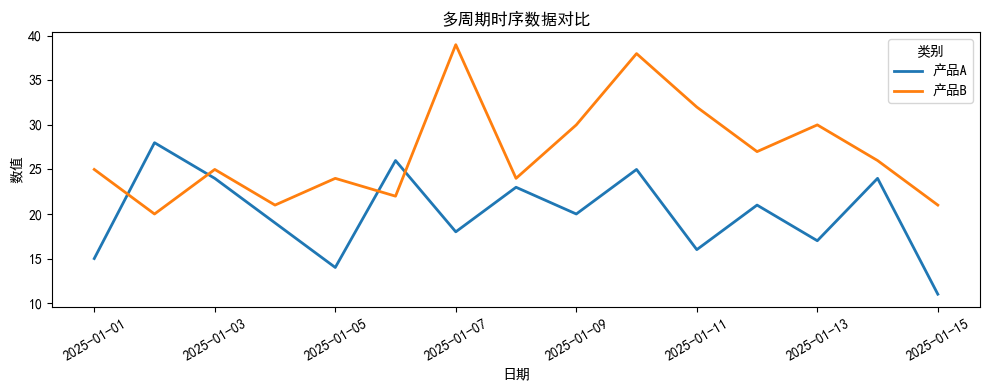

In [5]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=df, x="日期", y="数值", hue="类别", linewidth=2)

plt.title("多周期时序数据对比")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

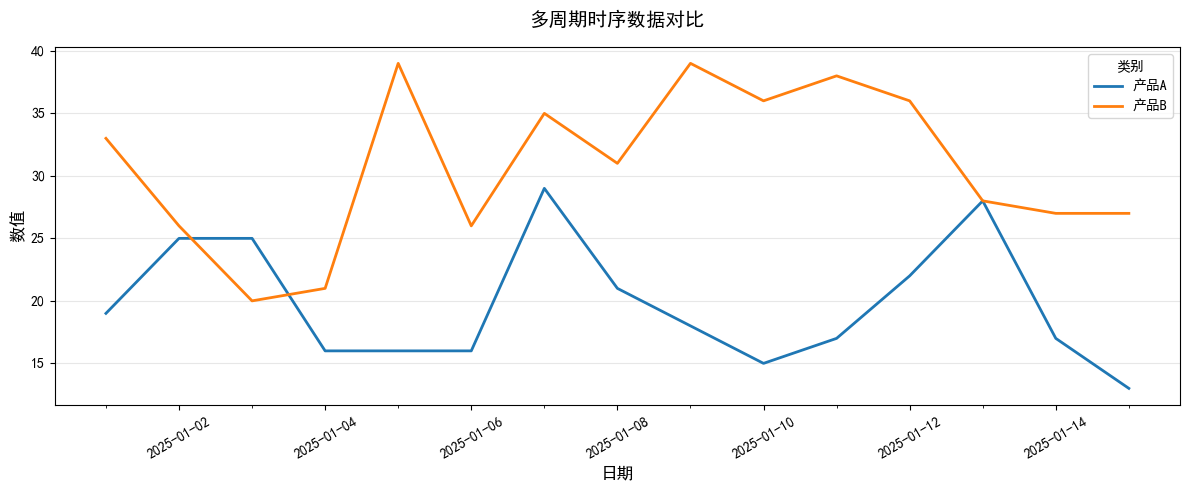

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates  # 时间轴核心工具

# 中文适配
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 生成连续15天日期
dates = pd.date_range("2025-01-01", periods=15, freq="D")

# 构造长表数据
df = pd.DataFrame(
    {
        "日期": np.tile(dates, 2),
        "数值": np.concatenate([np.random.randint(10, 30, 15), np.random.randint(20, 40, 15)]),
        "类别": ["产品A"] * 15 + ["产品B"] * 15
    }
)

# 确保日期列为datetime（好习惯，防止外部导入数据是字符串）
df["日期"] = pd.to_datetime(df["日期"])

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="日期", y="数值", hue="类别", linewidth=2)

# ========== 关键：专业时间轴配置（和普通图拉开差距的核心代码） ==========
ax = plt.gca()
# 1. 设置主刻度：每2天显示一个刻度，避免拥挤
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
# 2. 格式化日期标签，只显示 月-日，精简文字
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# 3. 次刻度每天都有小分隔线
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.title("多周期时序数据对比", fontsize=14, pad=15)
plt.xlabel("日期", fontsize=12)
plt.ylabel("数值", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)  # 增加横向网格，更适合读数
plt.tight_layout()
plt.show()